# In-Class Assignment 5

_Thursday, September 10, 2026_

_How to use this notebook:_ 

**Locally**: Hover over the download symbol then to the `ipynb` option then **right-click** to _Save Link As_ to download the file. You can then open the notebook using `jupyter notebook ica5.ipynb` in your terminal.

**Remote**: You can open the notebook on Colab by hovering over the rocket symbol then select launch to colab. In doing so, any data needed for the plots can be click and dragged to the online workbook. By default, the file will go to `/content/` or `/content/sample_data`

**Credit: [Mike Zingale](https://github.com/zingale)** for the Polytrope Routines and Notes.

---

## Comparing Polytropes to MESA models, Interpreting MESA data with TULIPS

### Learning Objectives

- Determine which polytrope model best fits a MESA WD model and interpret those results
- Explore situations where Polytrope models can be utilized 
- Familiarize with plotting tool TULIPS for visualizing time-evolution MESA data

## Implementation

This is our main class that does the integration.  We initialize it with the polytopic index, and then it will integrate the system for us.  We can then plot it or get
the parameters $\xi_1$ and $-\xi_1^2 d\theta/d\xi |_{\xi_1}$.

From the readings in HKT 7.1-7.2. We found some of the following relations:

Equation 7.20-7.22:


$$
\Large
\rho(r) = \rho_{\rm{c}}\theta^{n}(r) 
$$

$$
\Large
P(r) =  P_{\rm{c}} \theta^{1+n}(r)
$$

$$
\Large
P_{\rm{c}} =  K \rho^{1+1/n}_{\rm{c}} 
$$

and 

Equation 7.25:

$$
\Large
r^{2}_{n} = \frac{(n+1)P_{c}}{4\pi G \rho^{2}_{c}}
$$

and 

$$
\Large
r = r_{n} \xi
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
class Polytrope:
    """a polytrope of index n"""
    def __init__(self, n, h0=1.e-2, tol=1.e-12):
        self.n = n
        self.xi = []
        self.theta = []
        self.dtheta_dxi = []
        
        self._integrate(h0, tol)

    def _integrate(self, h0, tol):
        """integrate the Lane-Emden system"""

        # our solution vector q = (y, z)
        q = np.zeros(2, dtype=np.float64)
        xi = 0.0

        h = h0

        # initial conditions
        q[0] = 1.0
        q[1] = 0.0

        while h > tol:
            # 4th order RK integration -- first find the slopes
            k1 = self._rhs(xi, q)
            k2 = self._rhs(xi+0.5*h, q+0.5*h*k1)
            k3 = self._rhs(xi+0.5*h, q+0.5*h*k2)
            k4 = self._rhs(xi+h, q+h*k3)

            # now update the solution to the new xi
            q += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
            xi += h

            # set the new stepsize--our systems is always convex
            # (theta'' < 0), so the intersection of theta' with the
            # x-axis will always be a conservative estimate of the
            # radius of the star.  Make sure that the stepsize does
            # not take us past that.
            R_est = xi - q[0]/q[1]

            if xi + h > R_est:
                h = -q[0]/q[1]

            # store the solution:
            self.xi.append(xi)
            self.theta.append(q[0])
            self.dtheta_dxi.append(q[1])

        self.xi = np.array(self.xi)
        self.theta = np.array(self.theta)
        self.dtheta_dxi = np.array(self.dtheta_dxi)

    def _rhs(self, xi, q):
        """ the righthand side of the LE system, q' = f"""

        f = np.zeros_like(q)

        # y' = z
        f[0] = q[1]
        
        # for z', we need to use the expansion if we are at xi = 0,
        # to avoid dividing by 0
        if xi == 0.0:
            f[1] = (2.0/3.0) - q[0]**self.n
        else:
            f[1] = -2.0*q[1]/xi - q[0]**self.n

        return f

    def get_params(self):
        """ return the standard polytrope parameters xi_1,
        and [-xi**2 theta']_{xi_1} """
        xi1 = self.xi[-1]
        p2 = -xi1**2 * self.dtheta_dxi[-1]
        return xi1, p2

## a. Comparing Polytropes to a CO WD MESA model

### **Individually/with the person next to you**:

1. Call the `Polytrope` [Class](https://docs.python.org/3/tutorial/classes.html) to compute the Polytrope solution for a range of indices.

Download the following model files locally. These data were produced using the MESA [`make_co_wd`](https://docs.mesastar.org/en/latest/test_suite/make_co_wd.html) test suite.

#### **Download**

* $0.6 M_{\odot}$ WD _profile_ data: [co_wd_profile.data](data/co_wd_profile.data);

> Hint: You can access the varible of the class by calling the class object followed by `.variable`. For obtaining $\xi$ that would be `p.xi`.


### Run the follow cells that will:

1. produce a Polytrope of index `n` for `n=0,1,/3/2,3`.
2. From these instances we will compute $\xi=r/r_n$, $\theta(\xi)$, and our constant $\theta_n$.
3. Next, we will load the data for the MESA profile analysis.
4. compute $P_{\rm{c}}$ and $\rho_{\rm{c}}$ using the central/max values from the `co_wd_profile.data` MESA model first
5. compute `r_n` using the central values from the MESA model 
6. use `r_n` to compute the physical radius ($r=r_n \xi$) of the polytrope!
7. Use $\rho_{\rm{c}}$ from the MESA data to compute the density ($\rho=\theta_{n}\rho_{\rm{c}}$)

> We have just computed polytropic profiles for four different indices, all normalized by the MESA WD model!

### Plot

7. Load the radius $r$ and density $\rho$ from the MESA data
8. plot (and label) them on the same plot as the MESA model from 0 to $r\approx 1\times 10^9$ cm.
10. Describe in a few sentences your results. 

In [3]:
## 1 results here
# produce a polytrope here
G = 6.67e-8
msun = 2e33    # g
rsun = 6.96e10 # cm

# the n iindex we wish to consider
indices = [0,1,3./2.,3] # n

# an array holding the polytrope call for each index
p_array = [Polytrope(n) for n in indices]
#print(p_array)

xi_array = [p_array[i].xi for i in range(len(indices))]
theta_array = [p_array[i].theta for i in range(len(indices))]
theta_n_array = [theta_array[i]**indices[i] for i in range(len(indices))]

In [4]:
## 2-3 results here
co_wd_profile = pd.read_csv('data/co_wd_profile.data',sep=r'\s+',header=4)
co_wd_profile.columns

co_wd_rhoc = 10**(max(co_wd_profile['logRho']))
co_wd_Pc = 10**(max(co_wd_profile['logP']))

In [5]:
# 4-6 results here - compute r_n here HKT 7.25, given above for reference
r_n_array = [np.sqrt((n+1)*(co_wd_Pc)/(4.*np.pi*G*co_wd_rhoc*co_wd_rhoc)) for n in indices]
r_poly_array = [xi_array[i] * r_n_array[i] for i in range(len(indices))]
rho_poly_array = [theta_n_array[i]*co_wd_rhoc for i in range(len(indices))]

# 7 results here - it will be in units of Rsun so you will need to convert to cm !
co_wd_radius = co_wd_profile['radius'] * rsun
co_wd_density = 10**(co_wd_profile['logRho'])

In [6]:
import seaborn as sns

sns.set_palette("mako", n_colors=4)

# you can uncomment this is you have a retina display and are running locally
#%config InlineBackend.figure_format='retina'

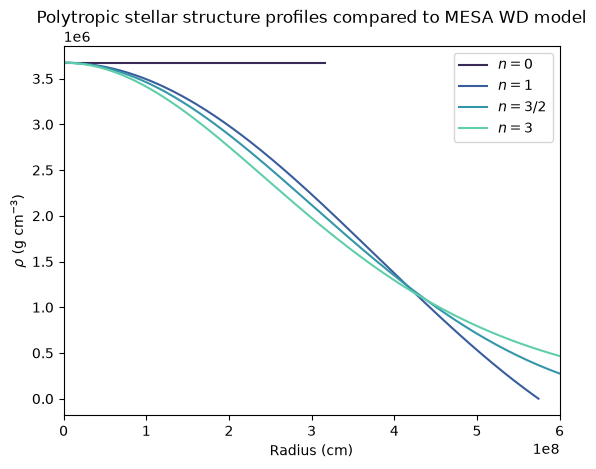

In [7]:
# 8 results here - plot the converted polytrope data and the raw MESA data

labels = [r'$n=0$',r'$n=1$',r'$n=3/2$',r'$n=3$']

for i in range(len(indices)):
    plt.plot(r_poly_array[i],rho_poly_array[i],label=labels[i],lw=1.5)
    
#plt.plot(co_wd_rad_var,co_wd_rho_var,label=r'MESA 0.6 $M_{\odot}$ WD Model',lw=1,ls='-.',color='k')
plt.xlim(0,6e8) # 6,000 km

plt.title(r'Polytropic stellar structure profiles compared to MESA WD model')
plt.legend(fontsize=10,fancybox=True,loc=1)
plt.xlabel(r'$\rm{Radius} \  (\rm{cm})$')
plt.ylabel(r'$\rho \ (\rm{g \ cm}^{-3})$')
plt.show()

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Which polytropic index best fits the CO WD MESA model profile? Is this expected? Comment briefly on the shape of the $n=0$ and $n=1$ profiles. 

    Your thoughtful response goes here.
   

## b. Comparing Polytropes to Brown Dwarf MESA models

### **Individually/with the person next to you**:

1. Call the `Polytrope` [Class](https://docs.python.org/3/tutorial/classes.html) to compute the Polytrope solution for a range of indices.

Download the following model files locally. These data were produced using the [`make_brown_dwarf`](https://docs.mesastar.org/en/latest/test_suite/make_brown_dwarf.html) test suite.

#### **Download**

* $\sim31 M_{Jupiter}$ Brown Dwarf _profile_ data: [0p03Msun_1RJup_profile.data](data/0p03Msun_1RJup_profile.data);


### Run the follow cells that will:

1. produce a Polytrope of index `n` for `n=0,1,/3/2,3`.
2. From these instances we will compute $\xi=r/r_n$, $\theta(\xi)$, and our constant $\theta_n$.
3. Next, we will load the data for the MESA profile analysis.
4. compute $P_{\rm{c}}$ and $\rho_{\rm{c}}$ using the central/max values from the `0p03Msun_1RJup_profile.data` MESA model now
5. compute `r_n` using the central values from the MESA model 
6. use `r_n` to compute the physical radius ($r=r_n \xi$) of the polytrope!
7. Use $\rho_{\rm{c}}$ from the MESA data to compute the density ($\rho=\theta_{n}\rho_{\rm{c}}$)

> We have just computed polytropic profiles for four different indices, all normalized by the MESA WD model!

### Plot

7. Load the radius $r$ and density $\rho$ from the MESA data
8. plot (and label) them on the same plot as the MESA model from 0 to $r\approx 1\times 10^9$ cm.
10. Describe in a few sentences your results. 

In [8]:
## 2-3 results here
bd_profile = pd.read_csv('data/0p03Msun_1RJup_profile.data',sep=r'\s+',header=4)
bd_profile.columns

bd_rhoc = 10**(max(bd_profile['logRho']))
bd_Pc = 10**(max(bd_profile['logP']))

In [9]:
# 4-6 results here - compute r_n here HKT 7.25, given above for reference
r_n_array = [np.sqrt((n+1)*(bd_Pc)/(4.*np.pi*G*bd_rhoc*bd_rhoc)) for n in indices]
r_poly_array = [xi_array[i] * r_n_array[i] for i in range(len(indices))]
rho_poly_array = [theta_n_array[i]*bd_rhoc for i in range(len(indices))]

# 7 results here - it will be in units of Rsun so you will need to convert to cm !
bd_radius = bd_profile['radius'] * rsun
bd_density = 10**(bd_profile['logRho'])

In [10]:
sns.set_palette("rocket", n_colors=4)

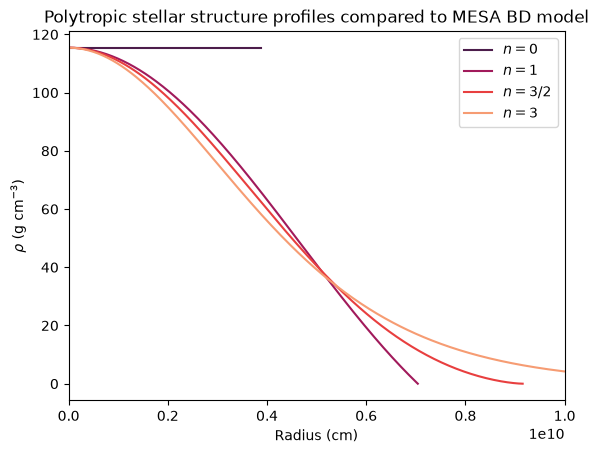

In [11]:
# 8 results here - plot the converted polytrope data and the raw MESA data

labels = [r'$n=0$',r'$n=1$',r'$n=3/2$',r'$n=3$']

for i in range(len(indices)):
    plt.plot(r_poly_array[i],rho_poly_array[i],label=labels[i],lw=1.5)
    
#plt.plot(bd_rad_var,bd_dens_var,label=r'1 $M_{Jupiter}$ Brown Dwarf Model',lw=1,ls='-.',color='k')
plt.xlim(0,1e10) # 

plt.title(r'Polytropic stellar structure profiles compared to MESA BD model')
plt.legend(fontsize=10,fancybox=True,loc=1)
plt.xlabel(r'$\rm{Radius} \  (\rm{cm})$')
plt.ylabel(r'$\rho \ (\rm{g \ cm}^{-3})$')
plt.show()

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Which polytropic index best fits the Brown Dwarf MESA model profile? Discuss briefly why this assumption might be valid for the WD and the Brown Dwarf.

    > hint: what is the specific heat for an ideal gas? denoted as $\gamma$ or $\Gamma$ in pols?

    Your response goes here. 
   

## c. Visualizing Stellar Structure with Tulips

To produce plots in the optional exercises we will use [mesaplot](https://github.com/rjfarmer/mesaplot) and [Tulips - _A Tool for Understanding the Lives, Interiors, and Physics of Stars_](https://astro-tulips.readthedocs.io/en/latest/index.html) and the Paper [here](https://www.sciencedirect.com/science/article/pii/S2213133721000688?via%3Dihub). Install each by performing the following commands to install them using `pip`:

‼️ **Important**

[**mesaPlot**](https://github.com/rjfarmer/mesaplot)

````{note}
`mesaplot` is not available on PyPI, so it can be installed using `pip` as:
```
pip install git+https://github.com/rjfarmer/mesaplot
```
````

[**Tulips** Installation](https://astro-tulips.readthedocs.io/en/latest/installation.html)

````{note}
`py_mesa_reader` is not available on PyPI, so it can be installed using `pip` as:
```
pip install astro-tulips
```
````

### **Individually/with the person next to you**:

### Download (if you have not already)
This directory which contains a collection of _profile_ data over the course of a $1M_{\odot}$ model from the pre-main sequence to the formation of a CO white dwarf [here](https://zenodo.org/records/5032250/files/1M_pre_ms_to_wd.tar.gz?download=1).


We will use the tool [**TULIPS: A Tool for Understanding the Lives, Interiors, and Physics of Stars**] (https://astro-tulips.readthedocs.io/en/latest/index.html) to look at some MESA profile data. 

1. Once the data are download, be sure to unzip them and place them in the correct location and set your path. 
2. Then, run the cells below to load the profile and history datasets. 

> Note: this will not work as is, you will need to change the path from mine: `SINGLE_M11_DIR`;

3. Run the cell below after successfully loading the data to produce: 
    - [energy and mixing diagram](https://astro-tulips.readthedocs.io/en/latest/energy_and_mixing_diagram.html)
    - [property profile diagram](https://astro-tulips.readthedocs.io/en/latest/property_profile_diagram.html) of the stellar profile data for $\eta$, the degeneracy parameter $\eta=(\mu-m_{e}c^2)/k_{\rm{B}}T$, $\eta \gg 1$ for strong electron degeneracy. 
 

In [12]:
# Interactive matplotlib plotting for jupyter lab
#%matplotlib inline

# or If you use jupyter notebook
%matplotlib notebook

import matplotlib.pyplot as plt
import mesaPlot as mp
import tulips

# Specify directory of MESA model
SINGLE_M11_DIR = "/Users/carlnotsagan/Downloads/1M_pre_ms_to_wd/LOGS_all"

# create mesa plot instance and pass DIR location to load data
m11 = mp.MESA()
m11.loadHistory(f=SINGLE_M11_DIR)

In [13]:
# pass data to tulips to create our first plots !
#tulips.energy_and_mixing(## pass out loaded profile data here, time_ind=(0,-1,2), cmin=-10, cmax=10, show_total_mass=True,
#                         show_mix=True, show_mix_legend=True, fig_size=(8,6),
#                         output_fname='energy_mixing_diagrams')
#plt.show()

In [14]:
#from IPython.display import Video

#Video("energy_mixing_diagrams.mp4", embed=False, width=700, height=600)

In [15]:
#tulips.property_profile(##pass the data object here, time_ind=(0, -1), fps=5, cmin=-5,cmax=50,cmap='viridis',
#                        property_name='eta', num_rings=100, output_fname='property_diagrams_eta')
#plt.show()

In [16]:
#from IPython.display import Video

#Video("property_diagrams_eta.mp4", embed=True, width=700, height=600)

### **With your larger group, try to answer the following**:

Using the above plot, answer the following:

> Looking at the energy and mixing diagram: where and when is the star undergoing core H-burning, and is it convective?

    Your response here. 
    
> Looking at the energy and mixing diagram: when does the star becomes a white dwarf? What is the final mass? What could be happening in the intermediate phases?

    Your response here.
    
> Looking at the eta evolution when the star is about 0.7Msun remaining, at what mass coordinate can you identify the envelope and the CO core? After subsequent evolution what happens to most of the envelope and how can you tell?

    Your response here.